<a href="https://colab.research.google.com/github/nafilafiryal/data_mining/blob/main/6_Tugas1C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [5]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [6]:
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [7]:
df_clean = df.dropna()

print("Ukuran data awal:", df.shape)
print("Ukuran data setelah dibersihkan:", df_clean.shape)

Ukuran data awal: (2938, 22)
Ukuran data setelah dibersihkan: (1649, 22)


In [8]:
le = LabelEncoder()
df_clean = df_clean.copy()
df_clean['Country'] = le.fit_transform(df_clean['Country'])
df_clean['Status'] = le.fit_transform(df_clean['Status'])

In [12]:
y = df_clean['Life expectancy ']

X = df_clean.drop(columns=['Life expectancy '])

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (1649, 21)
Ukuran y: (1649,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Data training: (1319, 21)
Data testing: (330, 21)


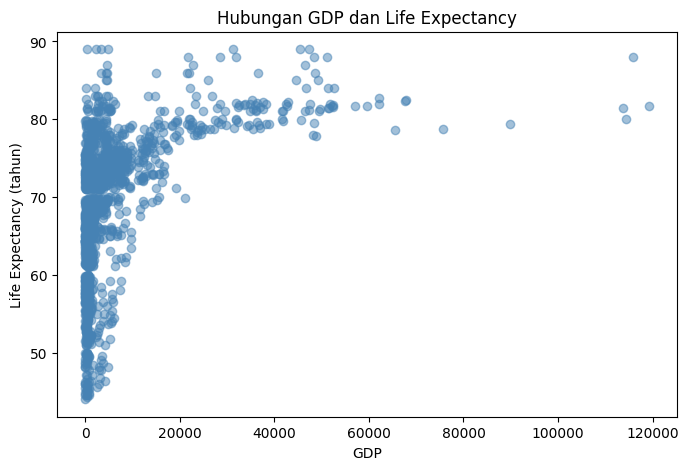

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['GDP'], df_clean['Life expectancy '], alpha=0.5, color='steelblue')
plt.xlabel("GDP")
plt.ylabel("Life Expectancy (tahun)")
plt.title("Hubungan GDP dan Life Expectancy")
plt.show()

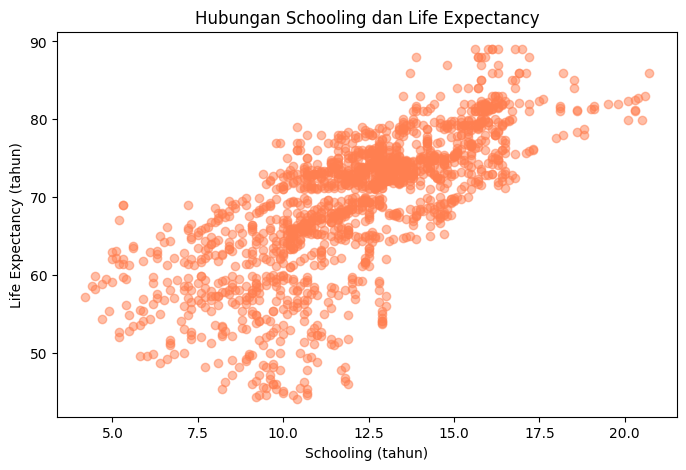

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Schooling'], df_clean['Life expectancy '], alpha=0.5, color='coral')
plt.xlabel("Schooling (tahun)")
plt.ylabel("Life Expectancy (tahun)")
plt.title("Hubungan Schooling dan Life Expectancy")
plt.show()

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model berhasil dilatih!")
print("Intercept:", model.intercept_)

Model berhasil dilatih!
Intercept: 281.25725193572566


In [19]:
koefisien = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=False)

print(koefisien)

                              Fitur     Koefisien
19  Income composition of resources  9.480719e+00
20                        Schooling  9.667016e-01
12                Total expenditure  1.058684e-01
4                     infant deaths  9.198318e-02
9                              BMI   2.616472e-02
13                      Diphtheria   1.420303e-02
11                            Polio  7.996214e-03
6            percentage expenditure  3.418477e-04
15                              GDP  1.163211e-05
16                       Population  5.370683e-10
8                          Measles  -9.454968e-06
0                           Country -4.451198e-04
7                       Hepatitis B -5.950027e-03
3                   Adult Mortality -1.621188e-02
17             thinness  1-19 years -4.126969e-02
18               thinness 5-9 years -4.608928e-02
10               under-five deaths  -6.929404e-02
1                              Year -1.132643e-01
5                           Alcohol -1.505654e-01


In [20]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")

RMSE  : 3.6090
R²    : 0.8166


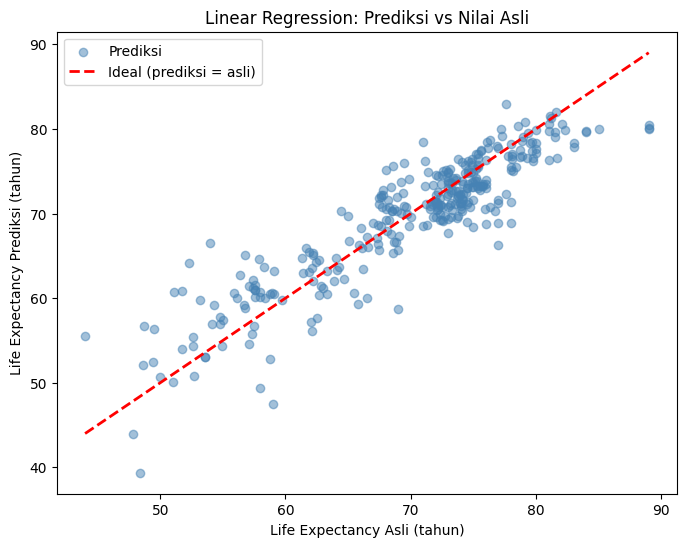

In [21]:
# Grafik perbandingan nilai asli vs prediksi
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', label='Prediksi')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Ideal (prediksi = asli)')
plt.xlabel("Life Expectancy Asli (tahun)")
plt.ylabel("Life Expectancy Prediksi (tahun)")
plt.title("Linear Regression: Prediksi vs Nilai Asli")
plt.legend()
plt.show()

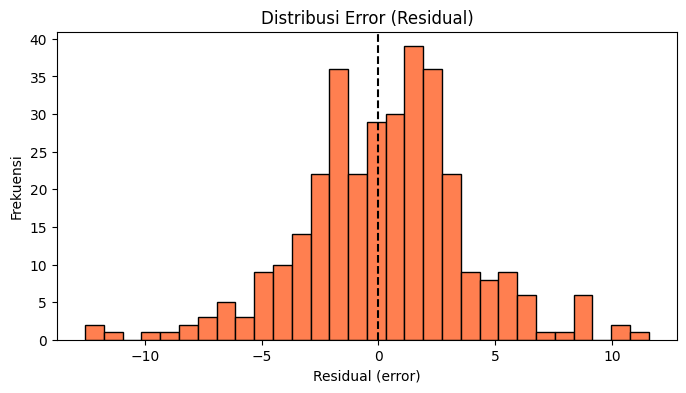

In [22]:
# Visualisasi residual (selisih prediksi dan asli)
residual = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residual, bins=30, color='coral', edgecolor='black')
plt.xlabel("Residual (error)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Error (Residual)")
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [23]:
contoh_data = X_test.iloc[[0]]

prediksi = model.predict(contoh_data)
nilai_asli = y_test.iloc[0]

print(f"Life Expectancy Asli   : {nilai_asli:.1f} tahun")
print(f"Life Expectancy Prediksi: {prediksi[0]:.1f} tahun")

Life Expectancy Asli   : 67.5 tahun
Life Expectancy Prediksi: 71.8 tahun


In [24]:
koefisien = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=False)

print(koefisien.to_string())

                              Fitur     Koefisien
19  Income composition of resources  9.480719e+00
20                        Schooling  9.667016e-01
12                Total expenditure  1.058684e-01
4                     infant deaths  9.198318e-02
9                              BMI   2.616472e-02
13                      Diphtheria   1.420303e-02
11                            Polio  7.996214e-03
6            percentage expenditure  3.418477e-04
15                              GDP  1.163211e-05
16                       Population  5.370683e-10
8                          Measles  -9.454968e-06
0                           Country -4.451198e-04
7                       Hepatitis B -5.950027e-03
3                   Adult Mortality -1.621188e-02
17             thinness  1-19 years -4.126969e-02
18               thinness 5-9 years -4.608928e-02
10               under-five deaths  -6.929404e-02
1                              Year -1.132643e-01
5                           Alcohol -1.505654e-01


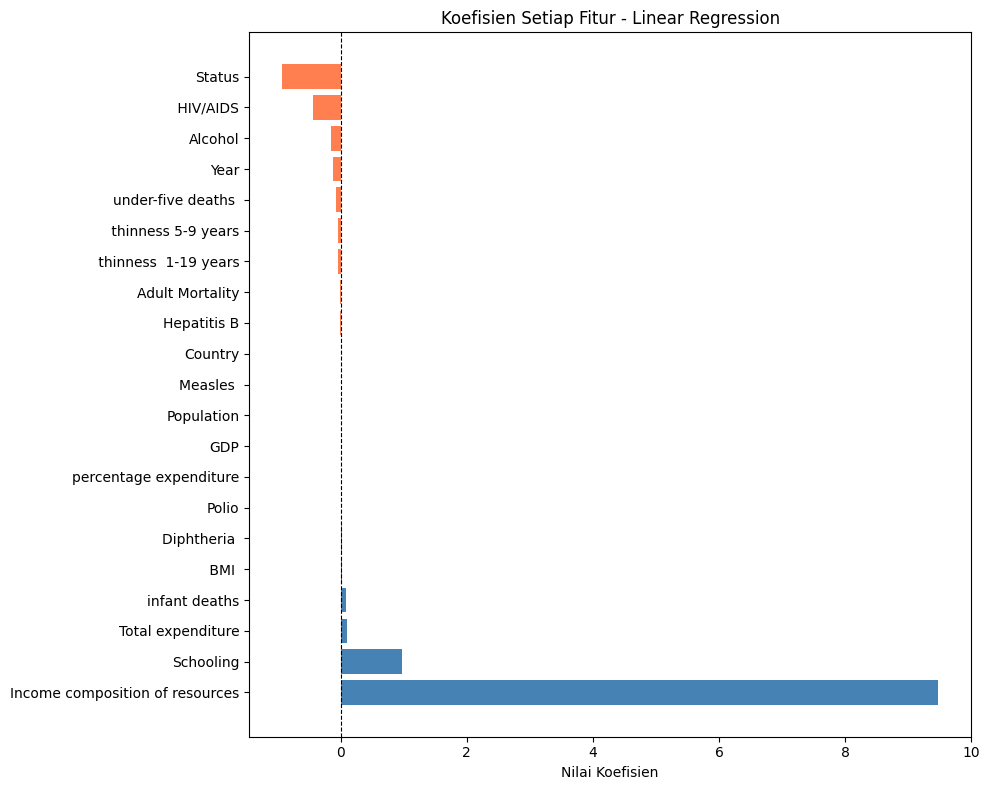

In [25]:
plt.figure(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'coral' for c in koefisien['Koefisien']]
plt.barh(koefisien['Fitur'], koefisien['Koefisien'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel("Nilai Koefisien")
plt.title("Koefisien Setiap Fitur - Linear Regression")
plt.tight_layout()
plt.show()